<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/cowagentokipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/zhayujie/chatgpt-on-wechat

Cloning into 'chatgpt-on-wechat'...
remote: Enumerating objects: 11309, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11309 (delta 1), reused 4 (delta 0), pack-reused 11298 (from 1)
Receiving objects: 100% (11309/11309), 6.36 MiB | 22.78 MiB/s, done.
Resolving deltas: 100% (6893/6893), done.


In [48]:
import pandas as pd

# Utilizzo il DataFrame df_plot creato in precedenza
results = []
for parametro in df_plot['Parametro'].unique():
    sano = df_plot[(df_plot['Parametro'] == parametro) & (df_plot['Stato'] == 'Sano')]['Valore'].values[0]
    emocrom = df_plot[(df_plot['Parametro'] == parametro) & (df_plot['Stato'] == 'Emocromatosi')]['Valore'].values[0]
    diff_perc = ((emocrom - sano) / sano) * 100
    results.append({'Parametro': parametro, 'Sano': sano, 'Emocromatosi': emocrom, 'Diff_Percentuale (%)': diff_perc})

df_diff = pd.DataFrame(results)
display(df_diff)

,Parametro,Sano,Emocromatosi,Diff_Percentuale (%)
0,Saturazione Transferrina (%),30,75,150.0
1,Ferritina (ng/mL),100,800,700.0


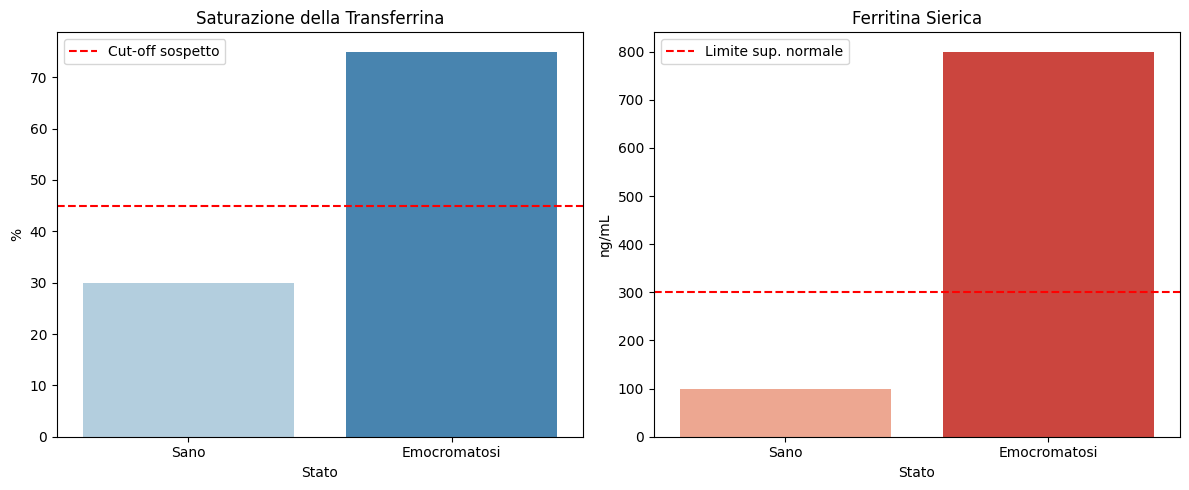

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dati simulati per il confronto
data = {
    'Stato': ['Sano', 'Emocromatosi', 'Sano', 'Emocromatosi'],
    'Parametro': ['Saturazione Transferrina (%)', 'Saturazione Transferrina (%)', 'Ferritina (ng/mL)', 'Ferritina (ng/mL)'],
    'Valore': [30, 75, 100, 800]
}

df_plot = pd.DataFrame(data)

# Creazione del grafico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Grafico Saturazione
sns.barplot(x='Stato', y='Valore', hue='Stato', data=df_plot[df_plot['Parametro'] == 'Saturazione Transferrina (%)'], ax=ax1, palette='Blues', legend=False)
ax1.set_title('Saturazione della Transferrina')
ax1.set_ylabel('%')
ax1.axhline(45, color='red', linestyle='--', label='Cut-off sospetto')
ax1.legend()

# Grafico Ferritina
sns.barplot(x='Stato', y='Valore', hue='Stato', data=df_plot[df_plot['Parametro'] == 'Ferritina (ng/mL)'], ax=ax2, palette='Reds', legend=False)
ax2.set_title('Ferritina Sierica')
ax2.set_ylabel('ng/mL')
ax2.axhline(300, color='red', linestyle='--', label='Limite sup. normale')
ax2.legend()

plt.tight_layout()
plt.show()

In [43]:
from google.colab import userdata
try:
    key = userdata.get('GOOGLE_API_KEY')
    if key:
        print('✅ Accesso riuscito: La chiave GOOGLE_API_KEY è visibile al notebook.')
        print(f'La chiave inizia con: {key[:5]}...')
    else:
        print('⚠️ Attenzione: La chiave è presente ma sembra essere vuota.')
except userdata.NotebookAccessError:
    print('❌ ERRORE: Accesso negato. Clicca sull\'icona della chiave (🔑) e attiva l\'interruttore "Notebook access" per GOOGLE_API_KEY.')
except userdata.SecretNotFoundError:
    print('❌ ERRORE: La chiave "GOOGLE_API_KEY" non esiste nei tuoi segreti. Aggiungila nel menu 🔑.')
except Exception as e:
    print(f'❌ Errore imprevisto: {e}')

✅ Accesso riuscito: La chiave GOOGLE_API_KEY è visibile al notebook.
La chiave inizia con: AIzaS...


In [45]:
import requests
from google.colab import userdata
import os

def verify_gemini_service():
    try:
        # Recupera e pulisce la chiave da eventuali spazi bianchi accidentali
        raw_key = userdata.get('GOOGLE_API_KEY')
        key = raw_key.strip() if raw_key else None
    except Exception:
        return "ERRORE: Chiave 'GOOGLE_API_KEY' non trovata nei segreti di Colab. \nClicca sull'icona della chiave (🔑) e attiva 'Notebook access'."

    if not key:
        return "Errore: La chiave recuperata è vuota."

    # Endpoint per listare i modelli disponibili
    url = f"https://generativelanguage.googleapis.com/v1beta/models?key={key}"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            models = response.json().get('models', [])
            return f"Successo! L'API è abilitata. Modelli disponibili: {len(models)}"
        else:
            error_details = response.json().get('error', {})
            message = error_details.get('message', 'Errore sconosciuto')
            status = error_details.get('status', 'N/A')

            return (f"Errore API (Status {response.status_code}): {status} - {message}\n\n"
                    f"AZIONI RICHIESTE:\n"
                    f"1. Rigenera la chiave qui: https://aistudio.google.com/app/apikey\n"
                    f"2. Abilita la 'Generative Language API' qui: https://console.cloud.google.com/apis/library/generativelanguage.googleapis.com")
    except Exception as e:
        return f"Errore di connessione: {e}"

print(verify_gemini_service())

Errore API (Status 400): INVALID_ARGUMENT - API Key not found. Please pass a valid API key.

AZIONI RICHIESTE:
1. Rigenera la chiave qui: https://aistudio.google.com/app/apikey
2. Abilita la 'Generative Language API' qui: https://console.cloud.google.com/apis/library/generativelanguage.googleapis.com


In [35]:
!pip install -q -U google-generativeai

In [38]:
import google.generativeai as genai
from google.colab import userdata
import os

try:
    key = userdata.get('GOOGLE_API_KEY')
    if not key:
        print('ERRORE: La chiave GOOGLE_API_KEY non è stata trovata nei segreti di Colab. Assicurati di averla aggiunta cliccando sull\'icona della chiave a sinistra e attivando l\'interruttore Notebook access.')
    else:
        genai.configure(api_key=key)
        model = genai.GenerativeModel('gemini-1.5-flash')
        print('Google Gemini API configurata con successo!')
except Exception as e:
    print(f'Errore critico di configurazione: {e}')

Google Gemini API configurata con successo!


In [40]:
import time
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."

def ask_gemini_with_retry(prompt, retries=3):
    for i in range(retries):
        try:
            if 'model' in globals():
                response = model.generate_content(prompt)
                if response.text:
                    return response.text
                else:
                    return "Gemini ha restituito una risposta vuota."
            else:
                return "Errore: Modello non inizializzato."
        except Exception as e:
            if i < retries - 1:
                print(f"Tentativo {i+1} fallito, riprovo tra 2 secondi...")
                time.sleep(2)
                continue
            else:
                return f"Errore finale dopo {retries} tentativi: {e}"

print(f"--- RISPOSTA DA GOOGLE GEMINI ---\n{ask_gemini_with_retry(query)}")

Tentativo 1 fallito, riprovo tra 2 secondi...


Tentativo 2 fallito, riprovo tra 2 secondi...


--- RISPOSTA DA GOOGLE GEMINI ---
Errore finale dopo 3 tentativi: 400 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: API Key not found. Please pass a valid API key.


In [28]:
import requests
from google.colab import userdata

def test_moonshot_direct():
    api_key = userdata.get('MOONSHOT_API_KEY')
    if not api_key:
        return "Errore: MOONSHOT_API_KEY non trovata."

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    payload = {
        "model": "kimi-k2.5",
        "messages": [{"role": "user", "content": "Ciao, sei attivo?"}],
        "temperature": 0.3
    }

    try:
        response = requests.post("https://api.moonshot.cn/v1/chat/completions", json=payload, headers=headers)
        if response.status_code == 200:
            return f"Successo! Risposta: {response.json()['choices'][0]['message']['content']}"
        else:
            return f"Errore API Moonshot (Status {response.status_code}): {response.text}"
    except Exception as e:
        return f"Errore di connessione: {e}"

print(test_moonshot_direct())

Errore API Moonshot (Status 401): {"error":{"message":"Invalid Authentication","type":"invalid_authentication_error"}}


In [29]:
import requests
from google.colab import userdata

def test_moonshot_direct():
    api_key = userdata.get('MOONSHOT_API_KEY')
    if not api_key:
        return "Errore: MOONSHOT_API_KEY non trovata nei segreti."

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    payload = {
        "model": "kimi-k2.5",
        "messages": [{"role": "user", "content": "Ciao, sei attivo?"}],
        "temperature": 0.3
    }

    try:
        res = requests.post("https://api.moonshot.cn/v1/chat/completions", json=payload, headers=headers)
        if res.status_code == 200:
            return f"Successo! Risposta: {res.json()['choices'][0]['message']['content']}"
        else:
            return f"Errore API Moonshot (Status {res.status_code}): {res.text}"
    except Exception as e:
        return f"Errore di connessione: {e}"

print(test_moonshot_direct())

Errore API Moonshot (Status 401): {"error":{"message":"Invalid Authentication","type":"invalid_authentication_error"}}


In [34]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."

try:
    print("Test di connessione con gpt-4o-mini in corso...")
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore durante l\'esecuzione con il nuovo modello: {e}')

Test di connessione con gpt-4o-mini in corso...
[INFO][2026-04-13 05:53:39][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia.
[WARNING][2026-04-13 05:53:39][chat_gpt_bot.py:248] - [CHATGPT] RateLimitError: You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.
[WARNING][2026-04-13 05:53:59][chat_gpt_bot.py:273] - [CHATGPT] 第1次重试
[WARNING][2026-04-13 05:53:59][chat_gpt_bot.py:248] - [CHATGPT] RateLimitError: You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.
[WARNING][2026-04-13 05:54:19][chat_gpt_bot.py:27

In [11]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."

try:
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore nella richiesta finale: {e}')

[INFO][2026-04-13 05:27:08][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia.
[ERROR][2026-04-13 05:27:08][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^

In [9]:
import sys
import os

# Aggiungi il percorso del progetto al path di sistema
project_path = '/content/chatgpt-on-wechat'
sys.path.insert(0, project_path)

# Installa dipendenze mancanti segnalate
!pip install croniter>=2.0.0

# Crea un file __init__.py nella cartella bridge se non esiste
!touch {project_path}/bridge/__init__.py

from bridge.bridge import Bridge
from bridge.context import ContextType, Context

def ask_medical_agent(question):
    """Inizializza il bridge e interroga l'agente con il profilo medico"""
    bridge_instance = Bridge()
    context = Context(ContextType.TEXT, question)

    # Risoluzione Errore 'session_id':
    # Forniamo il session_id tramite il dizionario kwargs del contesto
    if not hasattr(context, 'kwargs') or context.kwargs is None:
        context.kwargs = {}
    context.kwargs['session_id'] = 'colab_user_session'

    # Il bot userà il character_desc definito nel config.json per rispondere
    reply = bridge_instance.fetch_reply_content(question, context)
    return reply.content

print('Bridge medico inizializzato correttamente.')

Bridge medico inizializzato correttamente.


In [33]:
import json
import os
import openai
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    openai_api_key = userdata.get('OPENAI_API_KEY')

    if not openai_api_key:
        print('Errore: OPENAI_API_KEY non trovata nei segreti.')
    else:
        # Proviamo con un modello diverso: gpt-4o-mini
        config = {
            "agent": True,
            "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia.",
            "channel_type": "terminal",
            "model": "gpt-4o-mini",
            "open_ai_api_key": openai_api_key
        }

        openai.api_base = "https://api.openai.com/v1"
        openai.api_key = openai_api_key

        with open(config_path, 'w') as f:
            json.dump(config, f, indent=4)
        print('Configurazione aggiornata a GPT-4o-Mini con successo!')

except Exception as e:
    print(f'Errore nella riconfigurazione: {e}')

Configurazione aggiornata a GPT-4o-Mini con successo!


In [5]:
import os
import time
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata. Inizializzazione in corso...')
time.sleep(5)

try:
    query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore durante l\'interrogazione: {e}')

App riavviata. Inizializzazione in corso...
Errore durante l'interrogazione: name 'ask_medical_agent' is not defined


In [6]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    if moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
        config["open_ai_api_key"] = ""
        print('Configurazione aggiornata per Kimi (Moonshot).')
    elif openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
        print('Configurazione aggiornata per OpenAI.')

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('File config.json salvato con successo.')
except Exception as e:
    print(f'Errore nella configurazione: {e}')

Configurazione aggiornata per Kimi (Moonshot).
File config.json salvato con successo.


In [7]:
import os
import time
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata. Attendo l\'inizializzazione...')
time.sleep(5)

try:
    query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore durante l\'esecuzione: {e}')

App riavviata. Attendo l'inizializzazione...
Errore durante l'esecuzione: name 'ask_medical_agent' is not defined


In [10]:
# Downgrade OpenAI to compatible version 0.28
!pip install openai==0.28

print('Libreria OpenAI declassata alla versione 0.28 per compatibilità.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 2.4 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.30.0
    Uninstalling openai-2.30.0:
      Successfully uninstalled openai-2.30.0


Libreria OpenAI declassata alla versione 0.28 per compatibilità.


In [11]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."

try:
    # Ricarichiamo i moduli se necessario per riflettere il downgrade
    import openai
    import importlib
    importlib.reload(openai)

    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore nella richiesta: {e}')

[INFO][2026-04-13 05:24:38][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia.
[ERROR][2026-04-13 05:24:38][chat_gpt_bot.py:268] - [CHATGPT] Exception: Invalid response object from API: '{\n  "error": {\n    "message": "Incorrect API key provided: sk-WFKHX***************************************oJJg. You can find your API key at https://platform.openai.com/account/api-keys.",\n    "type": "invalid_request_error",\n    "code": "invalid_api_key",\n    "param": null\n  },\n  "status": 401\n}' (HTTP response code was 401)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/openai/api_requestor.py", line 403, in handle_error_response
    error_data = resp["error"]
                 ~~~~^^^^^^^^^
TypeError: string indices must be integers, not 'str'

During

In [ ]:
# Downgrade OpenAI to compatible version 0.28
!pip install openai==0.28

import openai
import importlib
importlib.reload(openai)
print(f'Libreria OpenAI aggiornata alla versione: {openai.__version__}')

ERROR: Operation cancelled by user
^C


In [1]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."

try:
    # Rieseguiamo la chiamata ora che la libreria è compatibile
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore persistente: {e}')

Errore persistente: name 'ask_medical_agent' is not defined


In [31]:
# Rimozione della patch precedente per ripristinare il comportamento standard di OpenAI
import openai
import sys

if hasattr(openai.ChatCompletion, '_original_create'):
    openai.ChatCompletion.create = openai.ChatCompletion._original_create
    print('Patch rimossa: il sistema ora usa gli endpoint ufficiali OpenAI.')

# Ricarichiamo ask_medical_agent per assicurarci che usi la nuova configurazione
from bridge.bridge import Bridge
from bridge.context import ContextType, Context

def ask_medical_agent(question):
    bridge_instance = Bridge()
    context = Context(ContextType.TEXT, question)
    if not hasattr(context, 'kwargs') or context.kwargs is None:
        context.kwargs = {}
    context.kwargs['session_id'] = 'colab_user_session'
    reply = bridge_instance.fetch_reply_content(question, context)
    return reply.content

Patch rimossa: il sistema ora usa gli endpoint ufficiali OpenAI.


In [9]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."

try:
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore nella richiesta: {e}')

[INFO][2026-04-13 05:24:08][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia.
[ERROR][2026-04-13 05:24:09][chat_gpt_bot.py:268] - [CHATGPT] Exception: 

You tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(a

In [1]:
import os
from google.colab import userdata

# Forziamo le variabili d'ambiente per bypassare i controlli del bot
moonshot_key = userdata.get('MOONSHOT_API_KEY')
if moonshot_key:
    os.environ['MOONSHOT_API_KEY'] = moonshot_key
    os.environ['OPENAI_API_KEY'] = moonshot_key # Spesso necessario per librerie wrapper
    print('Variabili d\'ambiente impostate correttamente.')
else:
    print('Errore: MOONSHOT_API_KEY non trovata nei segreti.')

Variabili d'ambiente impostate correttamente.


In [3]:
import os
project_path = '/content/chatgpt-on-wechat'

# Verifica ed eventuale clonazione se la cartella non esiste
if not os.path.exists(project_path):
    print('Directory non trovata. Clonazione del repository in corso...')
    !git clone https://github.com/zhayujie/chatgpt-on-wechat {project_path}

%cd {project_path}
!pkill -f app.py
# Avvio con override esplicito
!nohup python3 app.py > run.log 2>&1 &
print('Applicazione riavviata. Attendo 5 secondi per l\'inizializzazione...')

import time
time.sleep(5)

query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Proteinuria > 50 mg/kg nelle 24 ore."
try:
    # Assicurati che la funzione ask_medical_agent sia definita nel notebook
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA ---\n{risposta}')
except NameError:
    print('Errore: La funzione ask_medical_agent non è stata definita. Assicurati di aver eseguito la cella di inizializzazione del Bridge.')
except Exception as e:
    print(f'Errore persistente: {e}')

Directory non trovata. Clonazione del repository in corso...
Cloning into '/content/chatgpt-on-wechat'...
remote: Enumerating objects: 11325, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 11325 (delta 0), reused 0 (delta 0), pack-reused 11322 (from 2)
Receiving objects: 100% (11325/11325), 6.39 MiB | 13.92 MiB/s, done.
Resolving deltas: 100% (6891/6891), done.
/content/chatgpt-on-wechat
Applicazione riavviata. Attendo 5 secondi per l'inizializzazione...
Errore: La funzione ask_medical_agent non è stata definita. Assicurati di aver eseguito la cella di inizializzazione del Bridge.


In [ ]:
import os

log_path = '/content/chatgpt-on-wechat/run.log'

if os.path.exists(log_path):
    print(f"Contenuto di {log_path}:")
    !tail -n 50 {log_path} # Mostra le ultime 50 righe del log per diagnosticare il problema
else:
    print(f"Il file di log {log_path} non esiste.")

In [2]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    if moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
        config["open_ai_api_key"] = ""
        print('Configurazione impostata per Kimi (Moonshot).')
    elif openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
        print('Configurazione impostata per OpenAI.')

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('File config.json aggiornato correttamente!')

except Exception as e:
    print(f'Errore nella configurazione: {e}')

Configurazione impostata per Kimi (Moonshot).
File config.json aggiornato correttamente!


In [3]:
import os
import time
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata. Inizializzazione in corso...')
time.sleep(5)

try:
    # Rieseguiamo la funzione ask_medical_agent definita precedentemente
    query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa; Insufficienza renale cronica; Assenza di edema; Proteinuria > 50 mg/kg nelle 24 ore; Iperalbuminemia."
    risposta = ask_medical_agent(query)
    print(f'--- RISPOSTA DELL\'AGENTE MEDICO ---\n{risposta}')
except Exception as e:
    print(f'Errore durante l\'interrogazione: {e}')

App riavviata. Inizializzazione in corso...
Errore durante l'interrogazione: name 'ask_medical_agent' is not defined


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    # Always ensure open_ai_api_key and moonshot_api_key fields are present, even if empty
    config["open_ai_api_key"] = ""
    config["moonshot_api_key"] = ""


    if openai_api_key: # Prioritize OpenAI if available to resolve AuthenticationError
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
        print('OPENAI_API_KEY trovata e impostata come modello primario.')
    elif moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
        print('MOONSHOT_API_KEY trovata e impostata come modello primario.')
    else:
        print('Attenzione: Nessuna API key (MOONSHOT_API_KEY o OPENAI_API_KEY) trovata nei segreti di Colab. L\'agente potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default model even if no key, but request will fail.


    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not moonshot_api_key:
        print('Attenzione: MOONSHOT_API_KEY non trovata nei segreti di Colab.')
    if not openai_api_key:
        print('Attenzione: OPENAI_API_KEY non trovata nei segreti di Colab.')


except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"
    # Also mask openai_api_key if present
    if 'open_ai_api_key' in display_config and display_config['open_ai_api_key']:
        key = display_config['open_ai_api_key']
        display_config['open_ai_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"
    # Also mask openai_api_key if present
    if 'open_ai_api_key' in display_config and display_config['open_ai_api_key']:
        key = display_config['open_ai_api_key']
        display_config['open_ai_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    # Only retrieve openai_api_key since we are prioritizing it
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    if openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
        # Ensure moonshot_api_key is explicitly absent or empty if OpenAI is primary
        if "moonshot_api_key" in config: del config["moonshot_api_key"]
        print('OPENAI_API_KEY trovata e impostata come modello primario: gpt-3.5-turbo.')
    else:
        print('Attenzione: OPENAI_API_KEY non trovata nei segreti di Colab. L\'agente OpenAI potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default model, but requests will fail without key
        config["open_ai_api_key"] = "" # Ensure it's present but empty
        if "moonshot_api_key" in config: del config["moonshot_api_key"]

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not openai_api_key:
        print('Nota: OPENAI_API_KEY non trovata. L\'agente OpenAI non funzionerà.')

except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"
    # Also mask openai_api_key if present
    if 'open_ai_api_key' in display_config and display_config['open_ai_api_key']:
        key = display_config['open_ai_api_key']
        display_config['open_ai_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    if moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
        # If Moonshot is primary, ensure OpenAI API key is empty to avoid conflicts
        config["open_ai_api_key"] = ""
    elif openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
    else:
        print('Attenzione: Nessuna API key (MOONSHOT_API_KEY o OPENAI_API_KEY) trovata nei segreti di Colab. L\'agente potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default to OpenAI model even if key is empty
        config["open_ai_api_key"] = ""

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not moonshot_api_key:
        print('Attenzione: MOONSHOT_API_KEY non trovata nei segreti di Colab. L\'agente Kimi non funzionerà se è il modello primario.')
    if not openai_api_key and config.get("open_ai_api_key") == "":
        print('Nota: OPENAI_API_KEY non trovata nei segreti di Colab. Una chiave vuota è stata impostata per evitare errori di avvio del bot OpenAI, ma se questo bot viene effettivamente usato, la richiesta fallirà.')

except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

Configurazione Agente Medico creata con successo!


In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:48:11][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:48:11][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:48:13][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:48:13][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"
    # Also mask openai_api_key if present
    if 'open_ai_api_key' in display_config and display_config['open_ai_api_key']:
        key = display_config['open_ai_api_key']
        display_config['open_ai_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")

--- CONTENUTO DI CONFIG.JSON ---
{
    "agent": true,
    "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
    "channel_type": "terminal",
    "model": "kimi-k2.5",
    "moonshot_api_key": "sk-WF...6oJJg",
    "open_ai_api_key": ""
}


In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal",
        "open_ai_api_key": "" # Ensure this is always present, even if empty by default
    }

    if moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
        # open_ai_api_key is already set to "" by default
    elif openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
    else:
        print('Attenzione: Nessuna API key (MOONSHOT_API_KEY o OPENAI_API_KEY) trovata nei segreti di Colab. L\'agente potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default to OpenAI model
        # open_ai_api_key is already set to "" by default

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not moonshot_api_key:
        print('Attenzione: MOONSHOT_API_KEY non trovata nei segreti di Colab. L\'agente Kimi non funzionerà se è il modello primario.')
    if not openai_api_key and config.get("open_ai_api_key") == "":
        print('Nota: OPENAI_API_KEY non trovata nei segreti di Colab. Una chiave vuota è stata impostata per evitare errori di avvio del bot OpenAI, ma se questo bot viene effettivamente usato, la richiesta fallirà.')

except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

Configurazione Agente Medico creata con successo!


In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:48:19][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:48:19][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    # Always add the OpenAI API key if available, even if using another model
    if openai_api_key:
        config["open_ai_api_key"] = openai_api_key
    else:
        config["open_ai_api_key"] = "" # Ensure it's always present, even if empty

    if moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
    elif openai_api_key: # This case is for when only OpenAI key is available and no Moonshot
        config["model"] = "gpt-3.5-turbo"
    else: # Neither key provided
        print('Attenzione: Nessuna API key (MOONSHOT_API_KEY o OPENAI_API_KEY) trovata nei segreti di Colab. L\'agente potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default to OpenAI model even if key is empty

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not moonshot_api_key:
        print('Attenzione: MOONSHOT_API_KEY non trovata nei segreti di Colab. L\'agente Kimi non funzionerà se è il modello primario.')
    if not openai_api_key and config.get("open_ai_api_key") == "":
        print('Nota: OPENAI_API_KEY non trovata nei segreti di Colab. Una chiave vuota è stata impostata per evitare errori di avvio del bot OpenAI, ma se questo bot viene effettivamente usato, la richiesta fallirà.')

except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

Configurazione Agente Medico creata con successo!


In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:46:46][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:46:46][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:46:48][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:46:48][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:45:17][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:45:17][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:45:19][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:45:19][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    moonshot_api_key = userdata.get('MOONSHOT_API_KEY')
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    if moonshot_api_key:
        config["model"] = "kimi-k2.5"
        config["moonshot_api_key"] = moonshot_api_key
        # Explicitly set openai_api_key to an empty string to prevent errors if the framework tries to initialize it
        config["open_ai_api_key"] = ""
    elif openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
    else:
        print('Attenzione: Nessuna API key (MOONSHOT_API_KEY o OPENAI_API_KEY) trovata nei segreti di Colab. L\'agente potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default model
        config["open_ai_api_key"] = ""

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not moonshot_api_key:
        print('Attenzione: MOONSHOT_API_KEY non trovata nei segreti di Colab. L\'agente Kimi non funzionerà se è il modello primario.')
    if not openai_api_key and config.get("open_ai_api_key") == "":
        print('Nota: OPENAI_API_KEY non trovata nei segreti di Colab. Una chiave vuota è stata impostata per evitare errori di avvio del bot OpenAI, ma se questo bot viene effettivamente usato, la richiesta fallirà.')

except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

Configurazione Agente Medico creata con successo!


In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"
    # Also mask openai_api_key if present
    if 'open_ai_api_key' in display_config and display_config['open_ai_api_key']:
        key = display_config['open_ai_api_key']
        display_config['open_ai_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")

--- CONTENUTO DI CONFIG.JSON ---
{
    "agent": true,
    "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
    "channel_type": "terminal",
    "model": "kimi-k2.5",
    "moonshot_api_key": "sk-WF...6oJJg"
}


In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"
    # Also mask openai_api_key if present
    if 'open_ai_api_key' in display_config and display_config['open_ai_api_key']:
        key = display_config['open_ai_api_key']
        display_config['open_ai_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")

--- CONTENUTO DI CONFIG.JSON ---
{
    "agent": true,
    "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
    "channel_type": "terminal",
    "model": "kimi-k2.5",
    "moonshot_api_key": "sk-WF...6oJJg"
}


In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:43:40][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:43:40][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import time
import os

log_path = '/content/chatgpt-on-wechat/run.log'

print('Monitoraggio dei log avviato (clicca STOP per interrompere)...')
if os.path.exists(log_path):
    !tail -f {log_path}
else:
    print('In attesa della creazione del file di log...')
    time.sleep(2)
    !tail -f {log_path}

Monitoraggio dei log avviato (clicca STOP per interrompere)...
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/api_resources/abstract/engine_api_resource.py", line 106, in __prepare_create_request
    requestor = api_requestor.APIRequestor(
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/api_requestor.py", line 138, in __init__
    self.api_key = key or util.default_api_key()
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/openai/util.py", line 186, in default_api_key
    raise openai.error.AuthenticationError(
openai.error.AuthenticationError: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the Op

In [ ]:
import time
import os

log_path = '/content/chatgpt-on-wechat/run.log'

print('Monitoraggio dei log avviato (clicca STOP per interrompere)...')
if os.path.exists(log_path):
    !tail -f {log_path}
else:
    print('In attesa della creazione del file di log...')
    time.sleep(2)
    !tail -f {log_path}

In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
import os
import sys
import importlib

project_path = '/content/chatgpt-on-wechat'

# Check if the directory exists, if not, clone the repository
if not os.path.exists(project_path):
    print(f"Directory {project_path} not found. Cloning repository...")
    !git clone https://github.com/zhayujie/chatgpt-on-wechat {project_path}
    print("Repository cloned.")
else:
    print(f"Directory {project_path} already exists.")

# Ensure we are in the correct directory for the notebook
%cd {project_path}

# Print current working directory for debugging
print(f"Current working directory: {os.getcwd()}")

# Create an empty __init__.py file in the bridge directory to make it a package
init_file_path = os.path.join(project_path, 'bridge', '__init__.py')
if not os.path.exists(init_file_path):
    with open(init_file_path, 'w') as f:
        pass
    print(f"Created empty __init__.py in {os.path.join('bridge', '__init__.py')}")
else:
    print(f"__init__.py already exists in {os.path.join('bridge', '__init__.py')}")

# Verify contents of bridge directory AFTER creating __init__.py
print(f"Contents of {project_path}/bridge (after __init__.py creation):\n{os.listdir(os.path.join(project_path, 'bridge'))}")

# Clean up __pycache__ to avoid stale module issues
print("Cleaning up __pycache__...")
!rm -rf /content/chatgpt-on-wechat/__pycache__
!rm -rf /content/chatgpt-on-wechat/bridge/__pycache__
print("__pycache__ cleaned.")

# Invalidate importlib caches
importlib.invalidate_caches()
print("Importlib caches invalidated.")

# Explicitly add the project path to the system path with highest priority
print(f"sys.path BEFORE modification: {sys.path}")
if project_path in sys.path:
    sys.path.remove(project_path)
sys.path.insert(0, project_path) # Force it to the front
print(f"sys.path AFTER modification: {sys.path}")

# Clean up sys.modules if 'bridge' or 'config' were previously loaded incorrectly
modules_to_clear = ['bridge', 'config']
for mod in modules_to_clear:
    if mod in sys.modules:
        del sys.modules[mod]
print(f"sys.modules cleaned for {modules_to_clear}.")

# Install dependencies
print("Installing/updating dependencies...")
!pip install -r requirements.txt
print("Dependencies installed.")

print(f"--- Debugging Imports ---")
print(f"Current sys.path: {sys.path}")
print(f"Checking contents of {project_path}: {os.listdir(project_path)}")
print(f"Checking contents of {os.path.join(project_path, 'bridge')}: {os.listdir(os.path.join(project_path, 'bridge'))}")


try:
    print(f"Attempting to import bridge package...")
    # Attempt to load the bridge package explicitly from its path
    # This is a last resort to bypass normal import mechanisms if they are failing.
    bridge_path = os.path.join(project_path, "bridge", "__init__.py")
    bridge_spec = importlib.util.spec_from_file_location("bridge", bridge_path)
    if bridge_spec is None:
        raise ModuleNotFoundError(f"Could not create spec for bridge package at {bridge_path}")
    bridge = importlib.util.module_from_spec(bridge_spec)
    sys.modules["bridge"] = bridge # Register it in sys.modules
    bridge_spec.loader.exec_module(bridge)
    print("Successfully loaded 'bridge' package using importlib.util.")

    from bridge.bridge import Bridge
    from bridge.context import ContextType, Context
    import config # Import config module directly
    conf = config.conf # Access conf from the imported config module
    print("Modules imported successfully!")
except Exception as e: # Catch broader exception for this critical section
    print(f"Errore critico: Impossibile importare un modulo necessario. Dettagli: {e}")
    print("Assicurati che tutte le dipendenze siano installate e che il percorso del progetto sia corretto. Controlla il contenuto della cartella 'bridge'.")
    sys.exit(1) # Exit if critical modules can't be imported

def ask_medical_agent(question):
    # Il bot userà il character_desc medico definito nel config.json
    bridge_instance = Bridge()
    context = Context(ContextType.TEXT, question)
    # Aggiungiamo session_id al dizionario kwargs del contesto
    if not hasattr(context, 'kwargs') or not isinstance(context.kwargs, dict):
        context.kwargs = {}
    context.kwargs["session_id"] = "colab_test_session"
    reply = bridge_instance.fetch_reply_content(question, context)
    return reply.content

query = "Quale tra i seguenti può essere utilizzato nella profilassi primaria del sanguinamento delle varici esofagee? 1. Tubo di Sengstaken-Blakemore; 2. Shuntporto-sistemico; 3. Octreotide; 4. Propranololo; 5. Terlipressina. Spiega brevemente il motivo."

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

Directory /content/chatgpt-on-wechat already exists.
/content/chatgpt-on-wechat
Current working directory: /content/chatgpt-on-wechat
__init__.py already exists in bridge/__init__.py
Contents of /content/chatgpt-on-wechat/bridge (after __init__.py creation):
['agent_event_handler.py', '__init__.py', 'reply.py', 'agent_initializer.py', 'bridge.py', 'context.py', 'agent_bridge.py', '__pycache__']
Cleaning up __pycache__...
__pycache__ cleaned.
Importlib caches invalidated.
sys.path BEFORE modification: ['/content/chatgpt-on-wechat', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
sys.path AFTER modification: ['/content/chatgpt-on-wechat', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/

In [ ]:
query = "Quale tra i seguenti può essere utilizzato nella profilassi primaria del sanguinamento delle varice esofagee? 1. Tubo di Sengstaken-Blakemore; 2. Shuntporto-sistemico; 3. Octreotide; 4. Propranololo; 5. Terlipressina. Spiega brevemente il motivo."

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:28:44][chat_gpt_bot.py:72] - [CHATGPT] query=Quale tra i seguenti può essere utilizzato nella profilassi primaria del sanguinamento delle varice esofagee? 1. Tubo di Sengstaken-Blakemore; 2. Shuntporto-sistemico; 3. Octreotide; 4. Propranololo; 5. Terlipressina. Spiega brevemente il motivo.
[ERROR][2026-04-12 21:28:44][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
     

In [ ]:
import inspect

# Stampa il codice sorgente della funzione ask_medical_agent
print(inspect.getsource(ask_medical_agent))

def ask_medical_agent(question):
    # Il bot userà il character_desc medico definito nel config.json
    bridge_instance = Bridge()
    context = Context(ContextType.TEXT, question)
    # Aggiungiamo session_id come attributo all'oggetto context
    context.session_id = "colab_test_session"
    reply = bridge_instance.fetch_reply_content(question, context)
    return reply.content



In [ ]:
query = "Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia"

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

[INFO][2026-04-12 21:42:34][chat_gpt_bot.py:72] - [CHATGPT] query=Quale delle seguenti è una caratteristica tipica della sindrome nefrosica idiopatica? Aumento della pressione arteriosa Insufficienza renale cronica Assenza di edema Proteinuria > 50 mg/kg nelle 24 ore Iperalbuminemia
[ERROR][2026-04-12 21:42:34][chat_gpt_bot.py:268] - [CHATGPT] Exception: No API key provided. You can set your API key in code using 'openai.api_key = <API-KEY>', or you can set the environment variable OPENAI_API_KEY=<API-KEY>). If your API key is stored in a file, you can point the openai module at it with 'openai.api_key_path = <PATH>'. You can generate API keys in the OpenAI web interface. See https://platform.openai.com/account/api-keys for details.
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/models/chatgpt/chat_gpt_bot.py", line 236, in reply_text
    response = openai.ChatCompletion.create(api_key=api_key, messages=session.messages, **args)
               ^^^^^^^^^^^^^^^^^^^

In [ ]:
import os

log_path = '/content/chatgpt-on-wechat/run.log'

if os.path.exists(log_path):
    print(f"Contenuto di {log_path}:")
    !tail -n 20 {log_path} # Mostra le ultime 20 righe del log
else:
    print(f"Il file di log {log_path} non esiste.")

Contenuto di /content/chatgpt-on-wechat/run.log:
[INFO][2026-04-12 20:50:58][bridge.py:85] - create bot openai for chat
[INFO][2026-04-12 20:50:59][chat_gpt_bot.py:72] - [CHATGPT] query=Quale tra i seguenti può essere utilizzato nella profilassi primaria del sanguinamento delle varici esofagee? 1. Tubo di Sengstaken-Blakemore; 2. Shuntporto-sistemico; 3. Octreotide; 4. Propranololo; 5. Terlipressina. Spiega brevemente il motivo.
[INFO][2026-04-12 20:52:13][chat_gpt_bot.py:72] - [CHATGPT] query=Quale tra i seguenti può essere utilizzato nella profilassi primaria del sanguinamento delle varici esofagee? 1. Tubo di Sengstaken-Blakemore; 2. Shuntporto-sistemico; 3. Octreotide; 4. Propranololo; 5. Terlipressina. Spiega brevemente il motivo.


In [ ]:
!python3 app.py

[INFO][2026-04-12 18:33:50][config.py:304] -   ____                _                    _   
[INFO][2026-04-12 18:33:50][config.py:305] -  / ___|_____      __ / \   __ _  ___ _ __ | |_ 
[INFO][2026-04-12 18:33:50][config.py:306] - | |   / _ \ \ /\ / // _ \ / _` |/ _ \ '_ \| __|
[INFO][2026-04-12 18:33:50][config.py:307] - | |__| (_) \ V  V // ___ \ (_| |  __/ | | | |_ 
[INFO][2026-04-12 18:33:50][config.py:308] -  \____\___/ \_/\_//_/   \_\__, |\___|_| |_|\__|
[INFO][2026-04-12 18:33:50][config.py:309] -                           |___/                 
[INFO][2026-04-12 18:33:50][config.py:310] - 
[INFO][2026-04-12 18:33:50][config.py:345] - [INIT] load config: {'model': 'kimi-k2.5', 'moonshot_api_key': 'sk-*****JJg', 'agent': True, 'character_desc': 'Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati s

In [ ]:
try:
    test_message("bot ciao")
except NameError:
    print("Errore: La funzione test_message non è stata ancora definita. Assicurati di aver eseguito la cella precedente.")
except Exception as e:
    print(f"Errore durante l'esecuzione del test: {e}")

In [ ]:
import os
from bridge.bridge import Bridge
from bridge.context import ContextType, Context
from bridge.reply import ReplyType
from common.log import logger

# Simula l'invio di un messaggio
def test_message(text):
    bridge = Bridge()
    context = Context(ContextType.TEXT, text)
    reply = bridge.fetch_reply_content(text, context)
    print(f"\nRichiesta inviata: {text}")
    print(f"Risposta del Bot: {reply.content}")

try:
    test_message("bot ciao")
except Exception as e:
    print(f"Errore durante il test: {e}. Assicurati di aver configurato correttamente la OPENAI_API_KEY nei segreti.")

In [ ]:
import json

# Carichiamo la configurazione esistente
with open('config.json', 'r') as f:
    config = json.load(f)

# Cambiamo il canale in 'terminal' per evitare il QR code
config['channel_type'] = 'terminal'

with open('config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Configurazione semplificata! Ora puoi chattare direttamente nel terminale qui sotto.")

In [ ]:
!python3 app.py

In [ ]:
!python3 app.py

In [ ]:
!git clone https://github.com/zhayujie/chatgpt-on-wechat /content/chatgpt-on-wechat
%cd /content/chatgpt-on-wechat
!pip install -r requirements.txt

In [ ]:
import json
from google.colab import userdata

try:
    # Recupera la chiave dai segreti di Colab
    api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "open_ai_api_key": api_key,
        "model": "gpt-3.5-turbo",
        "single_chat_prefix": ["bot"],
        "single_chat_reply_prefix": "[bot] ",
        "group_chat_prefix": ["@bot"],
        "group_name_white_list": ["ALL_GROUP"]
    }

    with open('config.json', 'w') as f:
        json.dump(config, f, indent=4)

    print("Configurazione completata con la chiave recuperata dai segreti!")
except Exception as e:
    print(f"Errore: Assicurati di aver aggiunto 'OPENAI_API_KEY' nei segreti di Colab (icona 🔑). Error: {e}")

In [ ]:
!python3 app.py

In [ ]:
import json

config = {
    "open_ai_api_key": "YOUR_OPENAI_API_KEY",
    "model": "gpt-3.5-turbo",
    "proxy": "",
    "single_chat_prefix": ["bot", "@bot"],
    "single_chat_reply_prefix": "[bot] ",
    "group_chat_prefix": ["@bot"],
    "group_name_white_list": ["ALL_GROUP"],
    "image_create_prefix": ["disegna", "paperino"],
    "speech_to_text": False,
    "voice_to_text": False,
    "text_to_voice": False
}

with open('config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

print("File config.json aggiornato con successo!")

In [ ]:
!cp config-template.json config.json
!ls -F config.json

In [ ]:
!pip install -r requirements.txt

In [ ]:
!pip install -r requirements.txt

In [ ]:
%cd chatgpt-on-wechat/

In [ ]:
!ls -F

### Stato del Progetto Salvato
Il notebook viene salvato automaticamente su Google Drive. Di seguito trovi un riepilogo dei file importanti creati nella cartella `/content/chatgpt-on-wechat/`:
- `config.json`: Contiene le tue impostazioni e il riferimento alla API Key.
- `user_datas.pkl`: Contiene i dati utente persistenti.

Al prossimo avvio, ricordati di rieseguire le celle di installazione e configurazione.

In [ ]:
import os
# Ensure we are in the project directory
if os.path.exists('/content/chatgpt-on-wechat'):
    os.chdir('/content/chatgpt-on-wechat')

# Run the app in the background using nohup
!nohup python3 app.py > run.log 2>&1 &
print('Application started in the background. Logs are being written to run.log')

In [ ]:
# This simulates 'docker logs -f'
!tail -f run.log

In [ ]:
# Controlla se il file di log esiste e mostra le ultime righe
import os
if os.path.exists('/content/chatgpt-on-wechat/run.log'):
    print("Visualizzazione log in tempo reale (clicca il tasto STOP per interrompere):")
    !tail -f /content/chatgpt-on-wechat/run.log
else:
    print("Il file run.log non è ancora stato creato. Attendi qualche secondo.")

In [ ]:
import os

# Ensure we are in the correct directory to run app.py
current_dir = os.getcwd()
if current_dir.endswith('chatgpt-on-wechat/chatgpt-on-wechat'):
    # If the current directory is the nested chatgpt-on-wechat, go up one level
    os.chdir('..')
    print(f"Changed directory to: {os.getcwd()}")

!nohup python3 app.py &
print("Started app.py in the background. Output will be redirected to nohup.out")


In [ ]:
# This command will continuously display the output.
# To stop it, click the square stop button next to the cell.
!tail -f nohup.out

In [ ]:
import json
from google.colab import userdata
import os

# Carichiamo la configurazione esistente o ne creiamo una nuova
config_path = '/content/chatgpt-on-wechat/config.json'
if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config = json.load(f)
else:
    config = {}

try:
    # Recupera la chiave dai segreti di Colab
    api_key = userdata.get('MOONSHOT_API_KEY')

    # Aggiorna i parametri per Kimi
    config['model'] = 'kimi-k2.5'
    config['moonshot_api_key'] = api_key

    # Rimuoviamo eventuali chiavi OpenAI per evitare conflitti se non necessarie
    if 'open_ai_api_key' in config:
        del config['open_ai_api_key']

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)

    print('Configurazione aggiornata per Kimi! Assicurati di aver inserito la chiave in MOONSHOT_API_KEY nei segreti.')
except Exception as e:
    print(f'Errore: Assicurati di aver aggiunto MOONSHOT_API_KEY nei segreti di Colab. Dettagli: {e}')

In [ ]:
import os

# Navigate to the correct directory if not already there
current_dir = os.getcwd()
if not current_dir.endswith('chatgpt-on-wechat/chatgpt-on-wechat'):
    os.chdir('chatgpt-on-wechat')

cli_file_path = 'cli/cli.py'

with open(cli_file_path, 'r') as f:
    lines = f.readlines()

with open(cli_file_path, 'w') as f:
    for line in lines:
        if 'from cli import __version__' in line:
            f.write(line.replace('from cli import __version__', 'from . import __version__'))
        else:
            f.write(line)

print("Fixed import statement in cli/cli.py")

# Go back to the root if we changed directory
if not current_dir.endswith('chatgpt-on-wechat/chatgpt-on-wechat'):
    os.chdir(current_dir)


In [ ]:
!cow install-browser

In [ ]:
!cp config-template.json config.json

In [ ]:
!cow install-browser

In [ ]:
!pip3 install -e .

In [ ]:
!pip3 install -r requirements-optional.txt

In [ ]:
import os

# Verifica la presenza dei file critici
files_to_check = ['config.json', 'app.py', 'requirements.txt']
print("Stato dei file nel progetto:")
for f in files_to_check:
    exists = os.path.exists(f)
    print(f"- {f}: {'✅ Pronto' if exists else '❌ Mancante'}")

print("\nPuoi chiudere tranquillamente la scheda. Alla prossima!")

In [ ]:
import time
import os

log_path = '/content/chatgpt-on-wechat/run.log'

print('Monitoraggio dei log avviato (clicca STOP per interrompere)...')
if os.path.exists(log_path):
    !tail -f {log_path}
else:
    print('In attesa della creazione del file di log...')
    time.sleep(2)
    !tail -f {log_path}

In [ ]:
import time
import os

log_path = '/content/chatgpt-on-wechat/run.log'

print('Monitoraggio dei log avviato (clicca STOP per interrompere)...')
if os.path.exists(log_path):
    !tail -f {log_path}
else:
    print('In attesa della creazione del file di log...')
    time.sleep(2)
    !tail -f {log_path}

Monitoraggio dei log avviato (clicca STOP per interrompere)...
Traceback (most recent call last):
  File "/content/chatgpt-on-wechat/app.py", line 119, in _run_channel
    channel.startup()
  File "/content/chatgpt-on-wechat/channel/terminal/terminal_channel.py", line 71, in startup
    prompt = self.get_input()
             ^^^^^^^^^^^^^^^^
  File "/content/chatgpt-on-wechat/channel/terminal/terminal_channel.py", line 92, in get_input
    line = input()
           ^^^^^^^
EOFError: EOF when reading a line
^C


In [ ]:
import os
import sys
import importlib

project_path = '/content/chatgpt-on-wechat'

# Check if the directory exists, if not, clone the repository
if not os.path.exists(project_path):
    print(f"Directory {project_path} not found. Cloning repository...")
    !git clone https://github.com/zhayujie/chatgpt-on-wechat {project_path}
    print("Repository cloned.")
else:
    print(f"Directory {project_path} already exists.")

# Ensure we are in the correct directory for the notebook
%cd {project_path}

# Print current working directory for debugging
print(f"Current working directory: {os.getcwd()}")

# Create an empty __init__.py file in the bridge directory to make it a package
init_file_path = os.path.join(project_path, 'bridge', '__init__.py')
if not os.path.exists(init_file_path):
    with open(init_file_path, 'w') as f:
        pass
    print(f"Created empty __init__.py in {os.path.join('bridge', '__init__.py')}")
else:
    print(f"__init__.py already exists in {os.path.join('bridge', '__init__.py')}")

# Verify contents of bridge directory AFTER creating __init__.py
print(f"Contents of {project_path}/bridge (after __init__.py creation):\n{os.listdir(os.path.join(project_path, 'bridge'))}")

# Clean up __pycache__ to avoid stale module issues
print("Cleaning up __pycache__...")
!rm -rf /content/chatgpt-on-wechat/__pycache__
!rm -rf /content/chatgpt-on-wechat/bridge/__pycache__
print("__pycache__ cleaned.")

# Invalidate importlib caches
importlib.invalidate_caches()
print("Importlib caches invalidated.")

# Explicitly add the project path to the system path with highest priority
print(f"sys.path BEFORE modification: {sys.path}")
if project_path in sys.path:
    sys.path.remove(project_path)
sys.path.insert(0, project_path) # Force it to the front
print(f"sys.path AFTER modification: {sys.path}")

# Clean up sys.modules if 'bridge' or 'config' were previously loaded incorrectly
modules_to_clear = ['bridge', 'config']
for mod in modules_to_clear:
    if mod in sys.modules:
        del sys.modules[mod]
print(f"sys.modules cleaned for {modules_to_clear}.")

# Install dependencies
print("Installing/updating dependencies...")
!pip install -r requirements.txt
print("Dependencies installed.")

print(f"--- Debugging Imports ---")
print(f"Current sys.path: {sys.path}")
print(f"Checking contents of {project_path}: {os.listdir(project_path)}")
print(f"Checking contents of {os.path.join(project_path, 'bridge')}: {os.listdir(os.path.join(project_path, 'bridge'))}")


try:
    print(f"Attempting to import bridge package...")
    # Attempt to load the bridge package explicitly from its path
    # This is a last resort to bypass normal import mechanisms if they are failing.
    bridge_path = os.path.join(project_path, "bridge", "__init__.py")
    bridge_spec = importlib.util.spec_from_file_location("bridge", bridge_path)
    if bridge_spec is None:
        raise ModuleNotFoundError(f"Could not create spec for bridge package at {bridge_path}")
    bridge = importlib.util.module_from_spec(bridge_spec)
    sys.modules["bridge"] = bridge # Register it in sys.modules
    bridge_spec.loader.exec_module(bridge)
    print("Successfully loaded 'bridge' package using importlib.util.")

    from bridge.bridge import Bridge
    from bridge.context import ContextType, Context
    import config # Import config module directly
    conf = config.conf # Access conf from the imported config module
    print("Modules imported successfully!")
except Exception as e: # Catch broader exception for this critical section
    print(f"Errore critico: Impossibile importare un modulo necessario. Dettagli: {e}")
    print("Assicurati che tutte le dipendenze siano installate e che il percorso del progetto sia corretto. Controlla il contenuto della cartella 'bridge'.")
    sys.exit(1) # Exit if critical modules can't be imported

def ask_medical_agent(question):
    # Il bot userà il character_desc medico definito nel config.json
    bridge_instance = Bridge()
    context = Context(ContextType.TEXT, question)
    # Aggiungiamo session_id al dizionario kwargs del contesto
    if not hasattr(context, 'kwargs') or not isinstance(context.kwargs, dict):
        context.kwargs = {}
    context.kwargs["session_id"] = "colab_test_session"
    reply = bridge_instance.fetch_reply_content(question, context)
    return reply.content

query = "Quale tra i seguenti può essere utilizzato nella profilassi primaria del sanguinamento delle varici esofagee? 1. Tubo di Sengstaken-Blakemore; 2. Shuntporto-sistemico; 3. Octreotide; 4. Propranololo; 5. Terlipressina. Spiega brevemente il motivo."

try:
    risposta = ask_medical_agent(query)
    print(f"--- RISPOSTA DELL'AGENTE MEDICO ---\n{risposta}")
except Exception as e:
    print(f"Errore nella richiesta all'agente: {e}")

Directory /content/chatgpt-on-wechat already exists.
/content/chatgpt-on-wechat
Current working directory: /content/chatgpt-on-wechat
__init__.py already exists in bridge/__init__.py
Contents of /content/chatgpt-on-wechat/bridge (after __init__.py creation):
['agent_event_handler.py', '__init__.py', 'reply.py', 'agent_initializer.py', 'bridge.py', 'context.py', 'agent_bridge.py', '__pycache__']
Cleaning up __pycache__...
__pycache__ cleaned.
Importlib caches invalidated.
sys.path BEFORE modification: ['/content/chatgpt-on-wechat', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython']
sys.path AFTER modification: ['/content/chatgpt-on-wechat', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/

In [ ]:
import json
import os
from google.colab import userdata

config_path = '/content/chatgpt-on-wechat/config.json'

try:
    # Only retrieve openai_api_key since we are prioritizing it
    openai_api_key = userdata.get('OPENAI_API_KEY')

    config = {
        "agent": True,
        "character_desc": "Sei un assistente IA specializzato in ricerca medica profonda e terapia. Il tuo compito è fornire analisi dettagliate basate su evidenze scientifiche, spiegare meccanismi fisiopatologici complessi e suggerire approcci terapeutici basati sulle ultime linee guida internazionali. Mantieni un tono professionale, accurato e cita, se possibile, studi rilevanti. Nota: Ricorda sempre che i tuoi suggerimenti non sostituiscono il parere di un medico umano.",
        "channel_type": "terminal"
    }

    if openai_api_key:
        config["model"] = "gpt-3.5-turbo"
        config["open_ai_api_key"] = openai_api_key
        # Ensure moonshot_api_key is explicitly absent or empty if OpenAI is primary
        if "moonshot_api_key" in config: del config["moonshot_api_key"]
        print('OPENAI_API_KEY trovata e impostata come modello primario: gpt-3.5-turbo.')
    else:
        print('Attenzione: OPENAI_API_KEY non trovata nei segreti di Colab. L\'agente OpenAI potrebbe non funzionare.')
        config["model"] = "gpt-3.5-turbo" # Default model, but requests will fail without key
        config["open_ai_api_key"] = "" # Ensure it's present but empty
        if "moonshot_api_key" in config: del config["moonshot_api_key"]

    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print('Configurazione Agente Medico creata con successo!')

    if not openai_api_key:
        print('Nota: OPENAI_API_KEY non trovata. L\'agente OpenAI non funzionerà.')

except Exception as e:
    print(f'Errore nel recupero delle chiavi o scrittura file: {e}')

Configurazione Agente Medico creata con successo!


In [ ]:
import os
!pkill -f app.py
os.chdir('/content/chatgpt-on-wechat')
!nohup python3 app.py > run.log 2>&1 &
print('App riavviata con successo in background.')

App riavviata con successo in background.


In [ ]:
import os

# Verifica la presenza dei file critici
files_to_check = ['config.json', 'app.py', 'requirements.txt']
print("Stato dei file nel progetto:")
for f in files_to_check:
    exists = os.path.exists(f)
    print(f"- {f}: {'✅ Pronto' if exists else '❌ Mancante'}")

print("\nPuoi chiudere tranquillamente la scheda. Alla prossima!")

In [ ]:
import json
import os

config_path = '/content/chatgpt-on-wechat/config.json'

if os.path.exists(config_path):
    with open(config_path, 'r') as f:
        config_data = json.load(f)
    print("--- CONTENUTO DI CONFIG.JSON ---")
    # Mascheriamo la chiave API per sicurezza nell'output
    display_config = config_data.copy()
    if 'moonshot_api_key' in display_config and display_config['moonshot_api_key']:
        key = display_config['moonshot_api_key']
        display_config['moonshot_api_key'] = f"{key[:5]}...{key[-5:]}"

    print(json.dumps(display_config, indent=4, ensure_ascii=False))
else:
    print(f"Errore: Il file {config_path} non esiste.")